## Cell 1 — Mount Drive & Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
OUTPUT_DIR = '/content/drive/MyDrive/insurance_fraud/processed/'
PLOT_DIR   = '/content/drive/MyDrive/insurance_fraud/plots/'
os.makedirs(PLOT_DIR, exist_ok=True)

print('✅ Drive mounted.')

Mounted at /content/drive
✅ Drive mounted.


## Cell 2 — Imports & Plot Style

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Color palette (matches project theme) ─────────────────────────────────────
NAVY    = '#0D1B3E'
CARD    = '#132447'
BLUE    = '#1A3A6B'
ACCENT  = '#1DB8C4'
GREEN   = '#22C97A'
RED     = '#E84C4C'
YELLOW  = '#F5C842'
PURPLE  = '#C87EFF'
GRAY    = '#8BA3BF'
ORANGE  = '#FF8C42'
WHITE   = '#FFFFFF'

FRAUD_COLORS = {0: GREEN, 1: RED}   # 0=non-fraud, 1=fraud

plt.rcParams.update({
    'figure.facecolor' : NAVY,
    'axes.facecolor'   : CARD,
    'axes.labelcolor'  : WHITE,
    'xtick.color'      : WHITE,
    'ytick.color'      : WHITE,
    'text.color'       : WHITE,
    'axes.titlecolor'  : WHITE,
    'axes.edgecolor'   : ACCENT,
    'grid.color'       : '#1D3557',
    'grid.alpha'       : 0.4,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
})

def save_plot(fig, filename):
    path = PLOT_DIR + filename
    fig.savefig(path, dpi=150, bbox_inches='tight', facecolor=NAVY)
    print(f'  💾 Saved → {path}')

print('✅ Imports done.')

✅ Imports done.


## Cell 3 — Load Dataset

In [ ]:
df = pd.read_parquet(OUTPUT_DIR + 'train_provider_merged.parquet')

print(f'✅ Dataset loaded: {df.shape[0]:,} providers × {df.shape[1]} features')
print(f'\n📋 Columns ({len(df.columns)}):')
for i, col in enumerate(df.columns, 1):
    dtype = str(df[col].dtype)
    nulls = df[col].isnull().sum()
    print(f'  {i:02d}. {col:<40} {dtype:<12} nulls={nulls}')

✅ Dataset loaded: 5,410 providers × 34 features

📋 Columns (34):
  01. Provider                                 object       nulls=0
  02. ip_claim_count                           float64      nulls=0
  03. ip_unique_patients                       float64      nulls=0
  04. ip_total_reimbursement                   float64      nulls=0
  05. ip_avg_reimbursement                     float64      nulls=0
  06. ip_max_reimbursement                     float64      nulls=0
  07. ip_total_deductible                      float64      nulls=0
  08. ip_avg_deductible                        float64      nulls=0
  09. ip_avg_stay_days                         float64      nulls=0
  10. ip_max_stay_days                         float64      nulls=0
  11. ip_total_stay_days                       float64      nulls=0
  12. ip_avg_patient_age                       float64      nulls=0
  13. ip_deceased_patient_count                float64      nulls=0
  14. ip_avg_chronic_cond                      floa

## Cell 4 — Basic Statistics

In [ ]:
fraud     = df[df['fraud_label'] == 1]
non_fraud = df[df['fraud_label'] == 0]

print('='*60)
print('  DATASET OVERVIEW')
print('='*60)
print(f'  Total providers      : {len(df):,}')
print(f'  Fraudulent providers : {len(fraud):,}  ({len(fraud)/len(df)*100:.1f}%)')
print(f'  Legit providers      : {len(non_fraud):,}  ({len(non_fraud)/len(df)*100:.1f}%)')
print(f'  Total features       : {df.shape[1]-1}')
print(f'  Missing values       : {df.isnull().sum().sum()}')
print('='*60)

print('\n📊 Key feature stats — Fraud vs Non-Fraud comparison:')
compare_cols = [
    'ip_claim_count', 'op_claim_count', 'ip_avg_reimbursement',
    'ip_avg_stay_days', 'total_unique_patients',
    'ip_avg_chronic_cond', 'ip_unique_attending_phys'
]
compare_cols = [c for c in compare_cols if c in df.columns]

rows = []
for col in compare_cols:
    rows.append({
        'Feature'        : col,
        'Non-Fraud (mean)': non_fraud[col].mean(),
        'Fraud (mean)'   : fraud[col].mean(),
        'Ratio F/NF'     : fraud[col].mean() / (non_fraud[col].mean() + 1e-9)
    })
compare_df = pd.DataFrame(rows).set_index('Feature')
print(compare_df.round(2).to_string())

  DATASET OVERVIEW
  Total providers      : 5,410
  Fraudulent providers : 506  (9.4%)
  Legit providers      : 4,904  (90.6%)
  Total features       : 33
  Missing values       : 0

📊 Key feature stats — Fraud vs Non-Fraud comparison:
                          Non-Fraud (mean)  Fraud (mean)  Ratio F/NF
Feature                                                             
ip_claim_count                        3.48         46.25       13.29
op_claim_count                       66.95        374.30        5.59
ip_avg_reimbursement               3363.58       9605.43        2.86
ip_avg_stay_days                      1.87          5.32        2.85
total_unique_patients                49.39        247.53        5.01
ip_avg_chronic_cond                   1.85          4.83        2.61
ip_unique_attending_phys              1.58          8.19        5.17


## Cell 5 — Plot 1: Class Distribution & Fraud Rate

  💾 Saved → /content/drive/MyDrive/insurance_fraud/plots/plot1_class_distribution.png


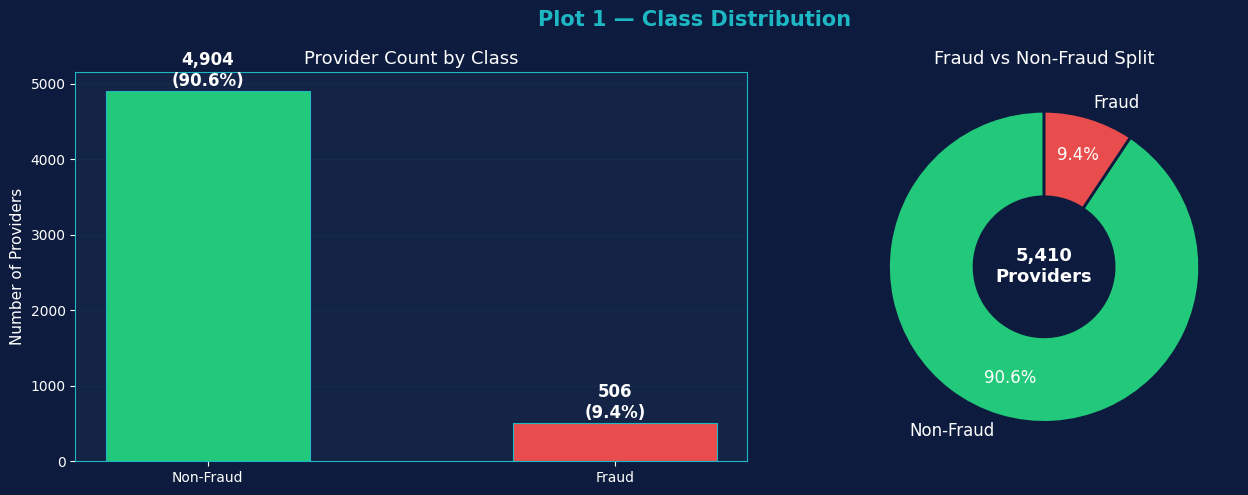

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Plot 1 — Class Distribution', fontsize=15, fontweight='bold', color=ACCENT)

# ── Bar chart ─────────────────────────────────────────────────────────────────
ax = axes[0]
counts = df['fraud_label'].value_counts().sort_index()
labels = ['Non-Fraud', 'Fraud']
colors = [GREEN, RED]
bars = ax.bar(labels, counts.values, color=colors, width=0.5,
              edgecolor=ACCENT, linewidth=0.8)
ax.set_title('Provider Count by Class')
ax.set_ylabel('Number of Providers')
ax.yaxis.grid(True)
ax.set_axisbelow(True)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 15,
            f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=12, color=WHITE, fontweight='bold')

# ── Donut chart ───────────────────────────────────────────────────────────────
ax = axes[1]
ax.set_facecolor(CARD)
wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=['Non-Fraud', 'Fraud'],
    colors=[GREEN, RED],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor=NAVY, linewidth=2),
    pctdistance=0.75
)
for text in texts + autotexts:
    text.set_color(WHITE)
    text.set_fontsize(12)
ax.text(0, 0, f'{len(df):,}\nProviders', ha='center', va='center',
        fontsize=13, color=WHITE, fontweight='bold')
ax.set_title('Fraud vs Non-Fraud Split')

plt.tight_layout()
save_plot(fig, 'plot1_class_distribution.png')
plt.show()

## Cell 6 — Plot 2: Financial Fraud Signals

  💾 Saved → /content/drive/MyDrive/insurance_fraud/plots/plot2_financial_signals.png


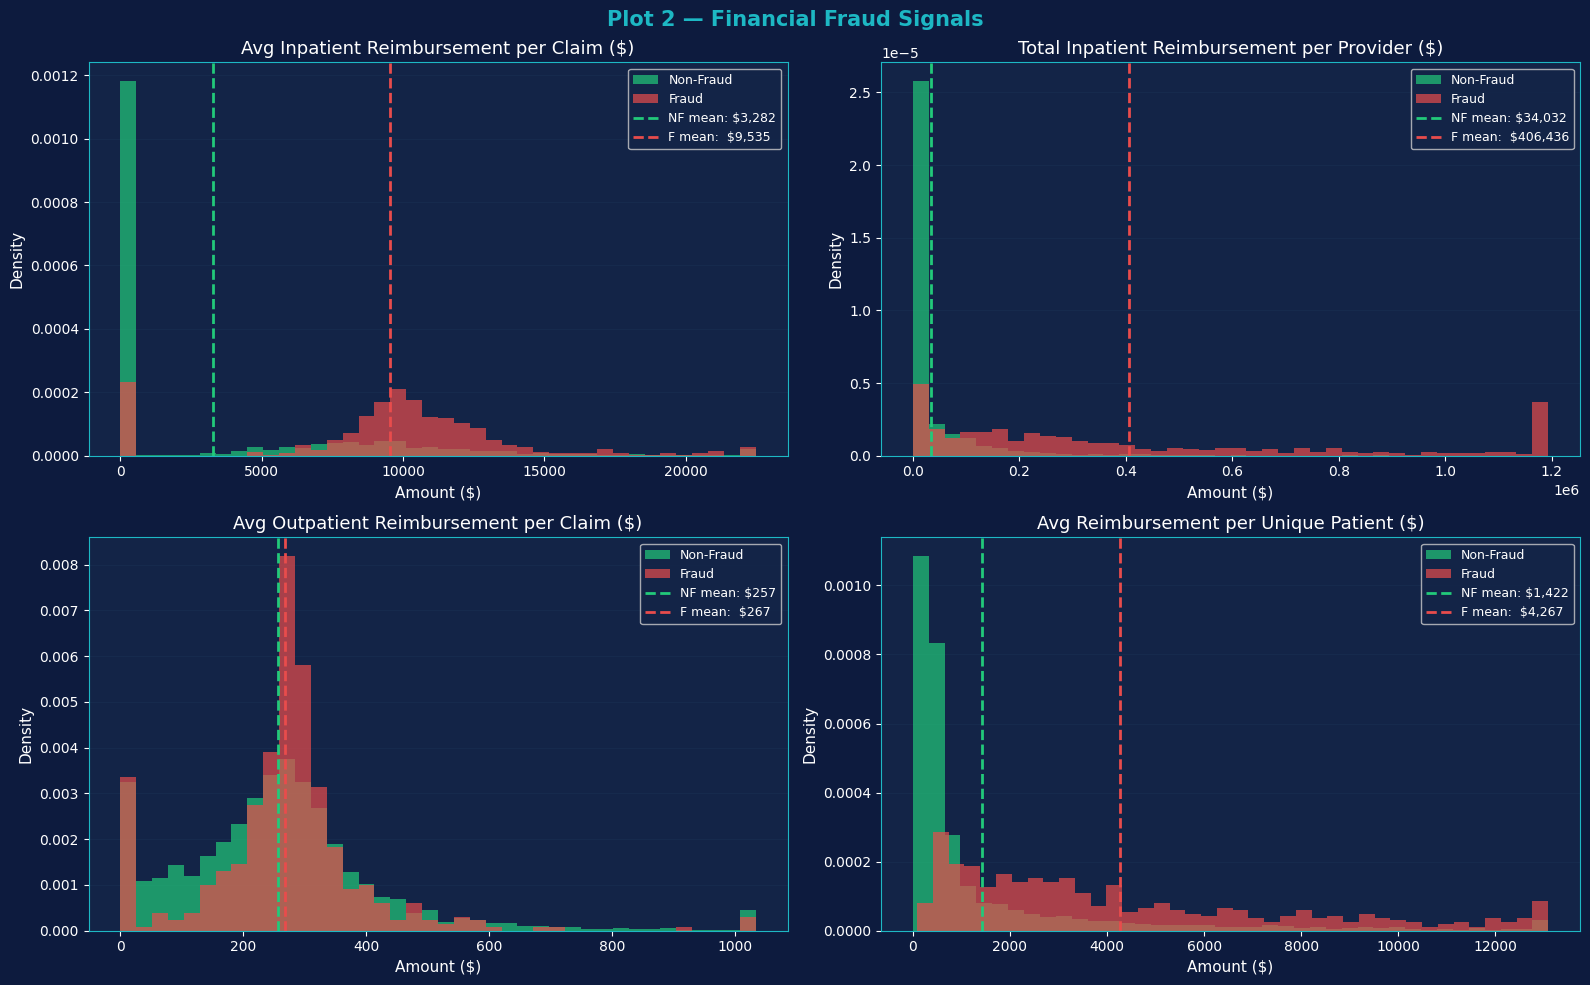

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Plot 2 — Financial Fraud Signals', fontsize=15, fontweight='bold', color=ACCENT)

financial_plots = [
    ('ip_avg_reimbursement',   'Avg Inpatient Reimbursement per Claim ($)'),
    ('ip_total_reimbursement', 'Total Inpatient Reimbursement per Provider ($)'),
    ('op_avg_reimbursement',   'Avg Outpatient Reimbursement per Claim ($)'),
    ('avg_reimb_per_patient',  'Avg Reimbursement per Unique Patient ($)'),
]

for ax, (col, title) in zip(axes.flatten(), financial_plots):
    if col not in df.columns:
        ax.text(0.5, 0.5, f'Column\n{col}\nnot found', ha='center', va='center',
                transform=ax.transAxes, color=GRAY)
        continue

    # Cap at 99th percentile to avoid extreme outliers skewing the plot
    cap = df[col].quantile(0.99)
    plot_data_nf = non_fraud[col].clip(0, cap)
    plot_data_f  = fraud[col].clip(0, cap)

    ax.hist(plot_data_nf, bins=40, color=GREEN, alpha=0.7,
            label='Non-Fraud', edgecolor='none', density=True)
    ax.hist(plot_data_f,  bins=40, color=RED,   alpha=0.7,
            label='Fraud',     edgecolor='none', density=True)

    # Mean lines
    ax.axvline(plot_data_nf.mean(), color=GREEN, linestyle='--', linewidth=2,
               label=f'NF mean: ${plot_data_nf.mean():,.0f}')
    ax.axvline(plot_data_f.mean(),  color=RED,   linestyle='--', linewidth=2,
               label=f'F mean:  ${plot_data_f.mean():,.0f}')

    ax.set_title(title)
    ax.set_xlabel('Amount ($)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)

plt.tight_layout()
save_plot(fig, 'plot2_financial_signals.png')
plt.show()

## Cell 7 — Plot 3: Patient Volume & Chronic Conditions

  💾 Saved → /content/drive/MyDrive/insurance_fraud/plots/plot3_patient_volume.png


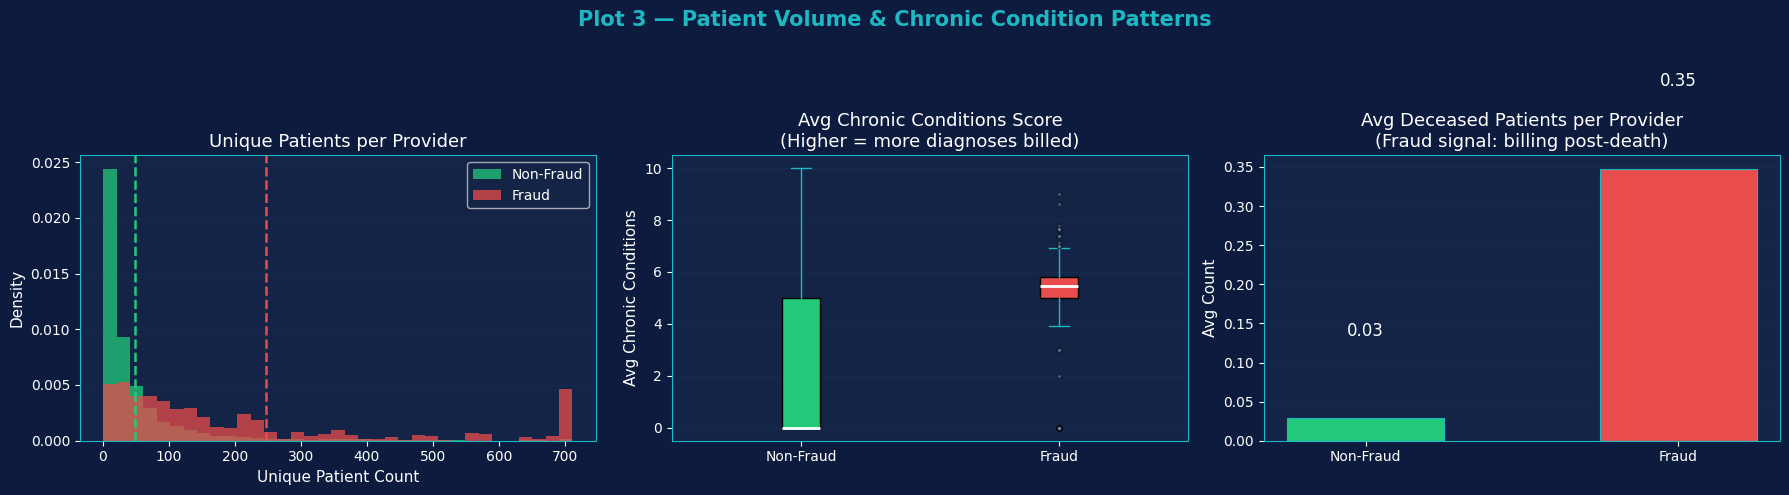

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Plot 3 — Patient Volume & Chronic Condition Patterns', fontsize=15, fontweight='bold', color=ACCENT)

# ── 1. Total unique patients per provider ─────────────────────────────────────
ax = axes[0]
cap = df['total_unique_patients'].quantile(0.99) if 'total_unique_patients' in df.columns else 500
col = 'total_unique_patients'
if col in df.columns:
    ax.hist(non_fraud[col].clip(0, cap), bins=35, color=GREEN, alpha=0.75,
            label='Non-Fraud', edgecolor='none', density=True)
    ax.hist(fraud[col].clip(0, cap),     bins=35, color=RED,   alpha=0.75,
            label='Fraud',     edgecolor='none', density=True)
    ax.axvline(non_fraud[col].mean(), color=GREEN, linestyle='--', linewidth=1.8)
    ax.axvline(fraud[col].mean(),     color=RED,   linestyle='--', linewidth=1.8)
    ax.set_title('Unique Patients per Provider')
    ax.set_xlabel('Unique Patient Count')
    ax.set_ylabel('Density')
    ax.legend()
    ax.yaxis.grid(True); ax.set_axisbelow(True)

# ── 2. Avg chronic conditions ─────────────────────────────────────────────────
ax = axes[1]
col = 'ip_avg_chronic_cond'
if col in df.columns:
    data_by_class = [non_fraud[col].dropna(), fraud[col].dropna()]
    bp = ax.boxplot(data_by_class, patch_artist=True,
                    medianprops=dict(color=WHITE, linewidth=2),
                    whiskerprops=dict(color=ACCENT),
                    capprops=dict(color=ACCENT),
                    flierprops=dict(marker='o', markerfacecolor=GRAY, markersize=3, alpha=0.4))
    bp['boxes'][0].set_facecolor(GREEN)
    bp['boxes'][1].set_facecolor(RED)
    ax.set_xticklabels(['Non-Fraud', 'Fraud'])
    ax.set_title('Avg Chronic Conditions Score\n(Higher = more diagnoses billed)')
    ax.set_ylabel('Avg Chronic Conditions')
    ax.yaxis.grid(True); ax.set_axisbelow(True)

# ── 3. Deceased patient count ─────────────────────────────────────────────────
ax = axes[2]
col = 'ip_deceased_patient_count'
if col in df.columns:
    means = [non_fraud[col].mean(), fraud[col].mean()]
    bars  = ax.bar(['Non-Fraud', 'Fraud'], means, color=[GREEN, RED],
                   width=0.5, edgecolor=ACCENT, linewidth=0.8)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.2f}', ha='center', va='bottom', fontsize=12, color=WHITE)
    ax.set_title('Avg Deceased Patients per Provider\n(Fraud signal: billing post-death)')
    ax.set_ylabel('Avg Count')
    ax.yaxis.grid(True); ax.set_axisbelow(True)

plt.tight_layout()
save_plot(fig, 'plot3_patient_volume.png')
plt.show()

## Cell 8 — Plot 4: Physician Reuse & Stay Duration

  💾 Saved → /content/drive/MyDrive/insurance_fraud/plots/plot4_physician_stay.png


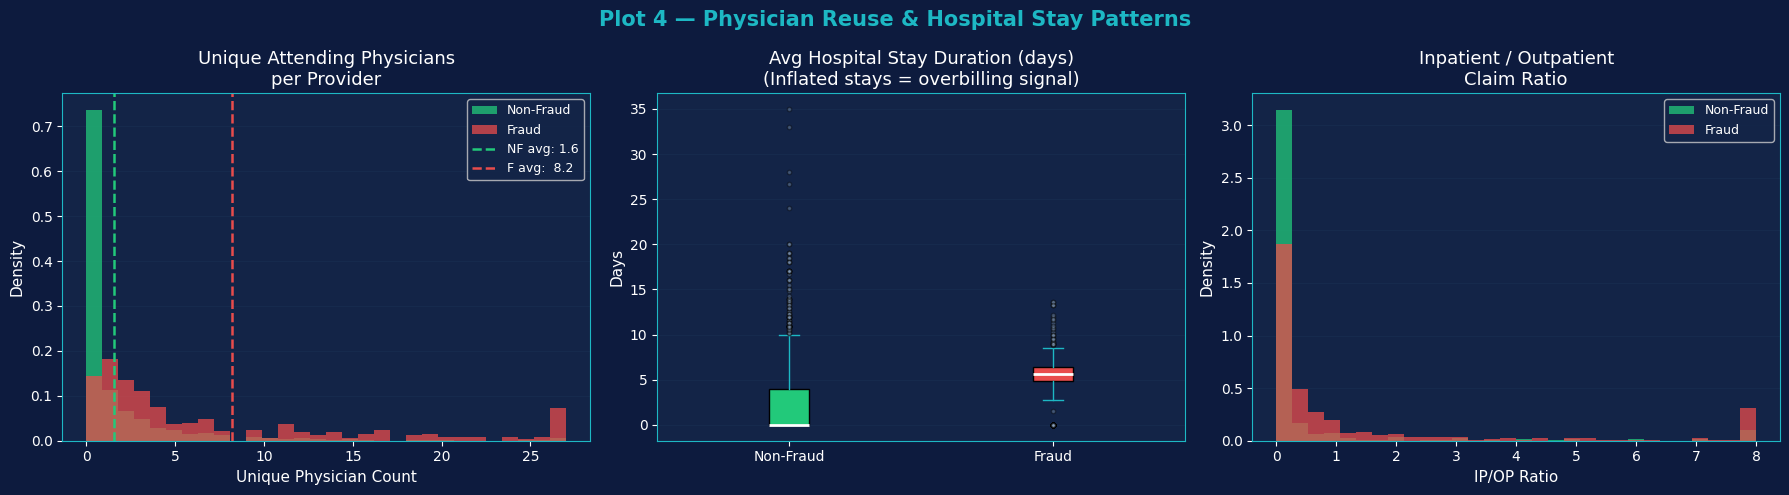

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Plot 4 — Physician Reuse & Hospital Stay Patterns', fontsize=15, fontweight='bold', color=ACCENT)

# ── 1. Unique attending physicians ────────────────────────────────────────────
ax = axes[0]
col = 'ip_unique_attending_phys'
if col in df.columns:
    cap = df[col].quantile(0.99)
    ax.hist(non_fraud[col].clip(0, cap), bins=30, color=GREEN, alpha=0.75,
            label='Non-Fraud', density=True, edgecolor='none')
    ax.hist(fraud[col].clip(0, cap),     bins=30, color=RED,   alpha=0.75,
            label='Fraud',     density=True, edgecolor='none')
    ax.axvline(non_fraud[col].mean(), color=GREEN, linestyle='--', linewidth=1.8,
               label=f"NF avg: {non_fraud[col].mean():.1f}")
    ax.axvline(fraud[col].mean(),     color=RED,   linestyle='--', linewidth=1.8,
               label=f"F avg:  {fraud[col].mean():.1f}")
    ax.set_title('Unique Attending Physicians\nper Provider')
    ax.set_xlabel('Unique Physician Count')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.yaxis.grid(True); ax.set_axisbelow(True)

# ── 2. Avg hospital stay days ─────────────────────────────────────────────────
ax = axes[1]
col = 'ip_avg_stay_days'
if col in df.columns:
    data_by_class = [non_fraud[col].dropna(), fraud[col].dropna()]
    bp = ax.boxplot(data_by_class, patch_artist=True,
                    medianprops=dict(color=WHITE, linewidth=2),
                    whiskerprops=dict(color=ACCENT),
                    capprops=dict(color=ACCENT),
                    flierprops=dict(marker='o', markerfacecolor=GRAY, markersize=3, alpha=0.4))
    bp['boxes'][0].set_facecolor(GREEN)
    bp['boxes'][1].set_facecolor(RED)
    ax.set_xticklabels(['Non-Fraud', 'Fraud'])
    ax.set_title('Avg Hospital Stay Duration (days)\n(Inflated stays = overbilling signal)')
    ax.set_ylabel('Days')
    ax.yaxis.grid(True); ax.set_axisbelow(True)

# ── 3. IP vs OP claim ratio ───────────────────────────────────────────────────
ax = axes[2]
col = 'ip_op_claim_ratio'
if col in df.columns:
    cap = df[col].quantile(0.97)
    ax.hist(non_fraud[col].clip(0, cap), bins=30, color=GREEN, alpha=0.75,
            label='Non-Fraud', density=True, edgecolor='none')
    ax.hist(fraud[col].clip(0, cap),     bins=30, color=RED,   alpha=0.75,
            label='Fraud',     density=True, edgecolor='none')
    ax.set_title('Inpatient / Outpatient\nClaim Ratio')
    ax.set_xlabel('IP/OP Ratio')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.yaxis.grid(True); ax.set_axisbelow(True)

plt.tight_layout()
save_plot(fig, 'plot4_physician_stay.png')
plt.show()

## Cell 9 — Plot 5: Top 10 Fraud-Discriminating Features (Box Plots)

Top 10 fraud-discriminating features:
  01. deductible_reimb_ratio                    NF=    927.57  F=     55.38  signal=0.940
  02. ip_total_reimbursement                    NF=  34055.57  F= 476854.76  signal=0.929
  03. ip_total_stay_days                        NF=     19.35  F=    265.57  signal=0.927
  04. ip_total_deductible                       NF=   3632.81  F=  48321.72  signal=0.925
  05. ip_claim_count                            NF=      3.48  F=     46.25  signal=0.925
  06. ip_unique_patients                        NF=      3.26  F=     40.76  signal=0.920
  07. ip_deceased_patient_count                 NF=      0.03  F=      0.35  signal=0.917
  08. op_total_reimbursement                    NF=  19138.15  F= 107495.28  signal=0.822
  09. op_claim_count                            NF=     66.95  F=    374.30  signal=0.821
  10. op_total_deductible                       NF=    186.26  F=   1038.50  signal=0.821
  💾 Saved → /content/drive/MyDrive/insurance_fraud/plots/plot5

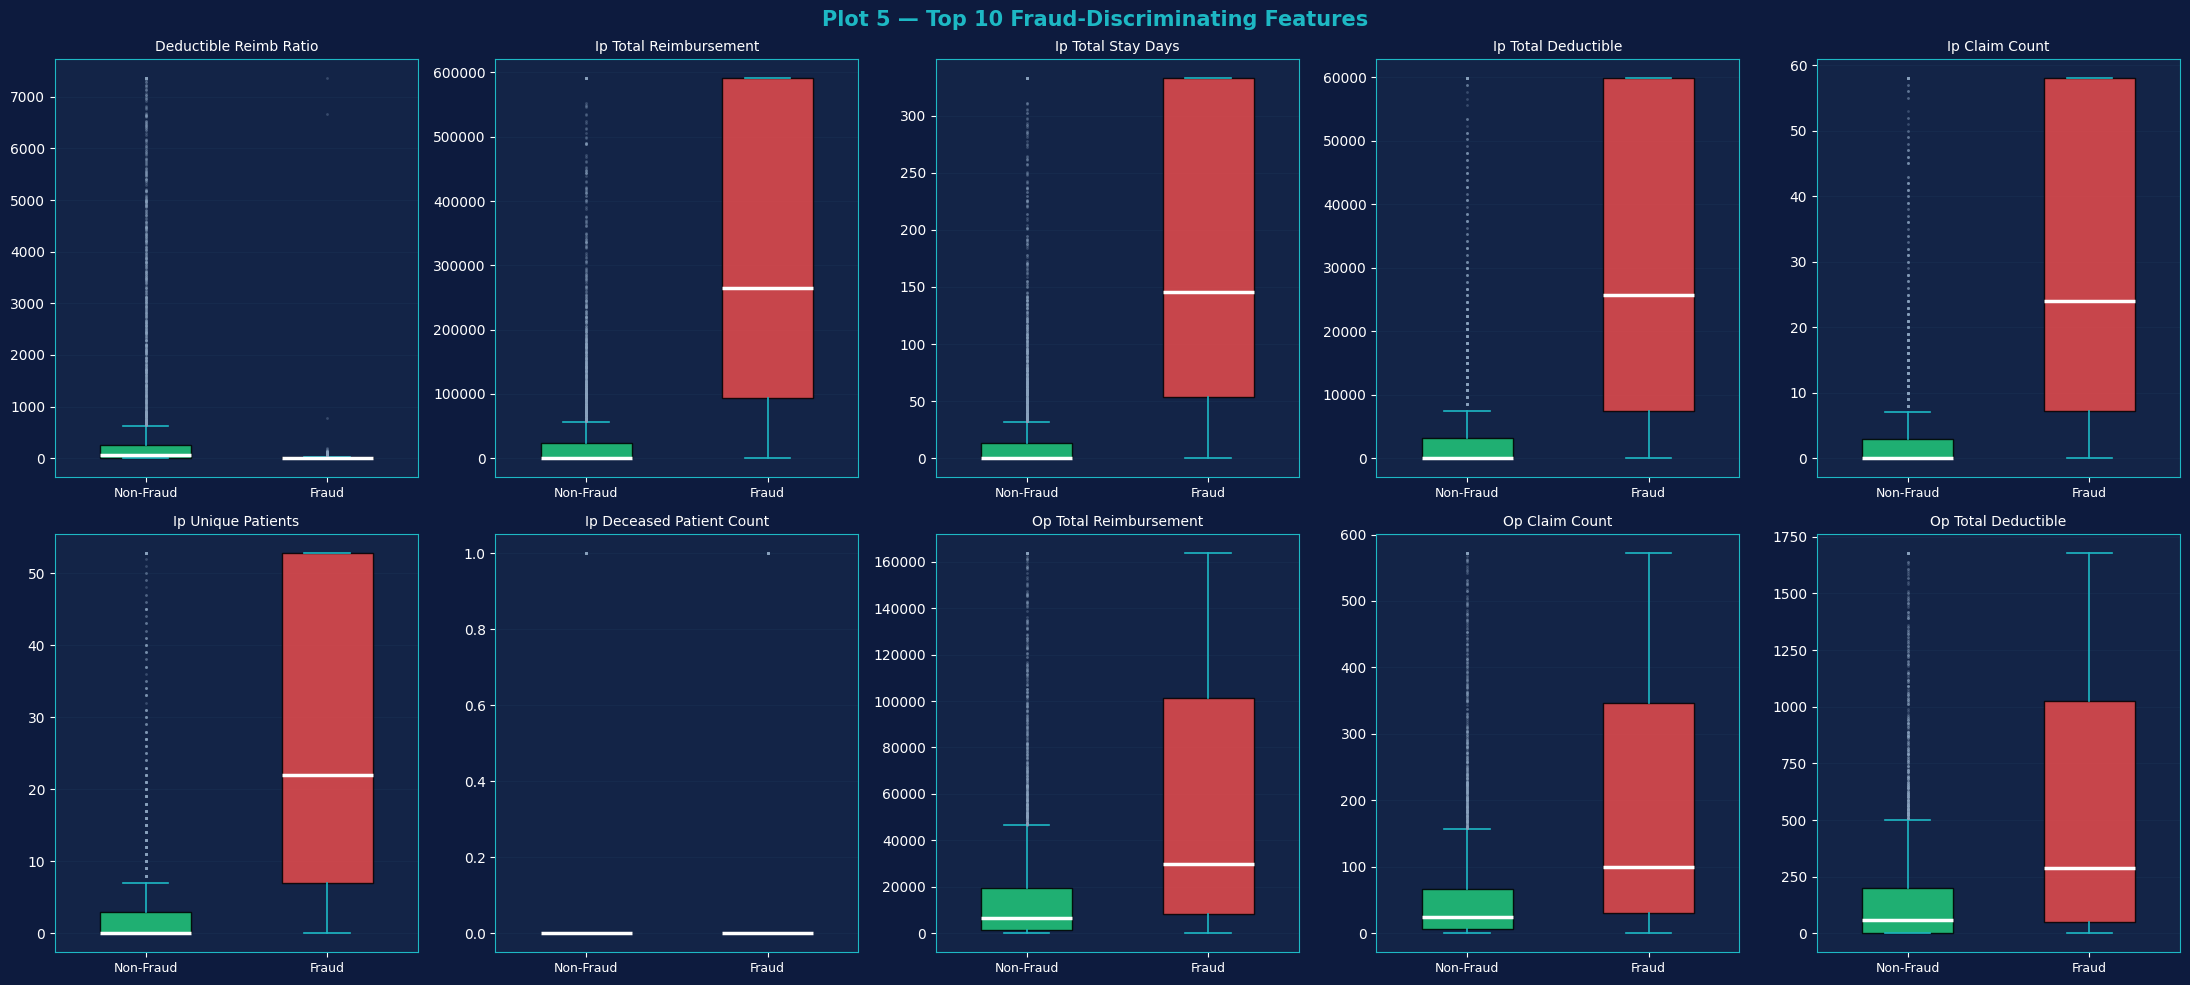

In [ ]:
# Select top numeric features with meaningful fraud signal
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'fraud_label']

# Rank features by how different their means are between fraud and non-fraud
signal_strength = []
for col in numeric_cols:
    nf_mean = non_fraud[col].mean()
    f_mean  = fraud[col].mean()
    # Normalised difference
    denom = max(abs(nf_mean), abs(f_mean), 1e-9)
    signal_strength.append((col, abs(f_mean - nf_mean) / denom))

signal_strength.sort(key=lambda x: x[1], reverse=True)
top_features = [col for col, _ in signal_strength[:10]]

print('Top 10 fraud-discriminating features:')
for i, (col, score) in enumerate(signal_strength[:10], 1):
    nf = non_fraud[col].mean()
    f  = fraud[col].mean()
    print(f'  {i:02d}. {col:<40}  NF={nf:>10.2f}  F={f:>10.2f}  signal={score:.3f}')

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
fig.suptitle('Plot 5 — Top 10 Fraud-Discriminating Features', fontsize=15, fontweight='bold', color=ACCENT)

for ax, col in zip(axes.flatten(), top_features):
    cap = df[col].quantile(0.97)
    data = [non_fraud[col].clip(0, cap).dropna(),
            fraud[col].clip(0, cap).dropna()]

    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color=WHITE, linewidth=2.5),
                    whiskerprops=dict(color=ACCENT, linewidth=1.2),
                    capprops=dict(color=ACCENT, linewidth=1.2),
                    flierprops=dict(marker='o', markerfacecolor=GRAY,
                                   markersize=2, alpha=0.3, markeredgecolor='none'))
    bp['boxes'][0].set_facecolor(GREEN)
    bp['boxes'][0].set_alpha(0.85)
    bp['boxes'][1].set_facecolor(RED)
    bp['boxes'][1].set_alpha(0.85)

    ax.set_xticklabels(['Non-Fraud', 'Fraud'], fontsize=9)
    # Shorten long column names for display
    short_name = col.replace('ip_', 'IP ').replace('op_', 'OP ').replace('_', ' ').title()
    ax.set_title(short_name, fontsize=10)
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)

plt.tight_layout()
save_plot(fig, 'plot5_top_features_boxplot.png')
plt.show()

## Cell 10 — Plot 6: Correlation Heatmap

  💾 Saved → /content/drive/MyDrive/insurance_fraud/plots/plot6_correlation_heatmap.png


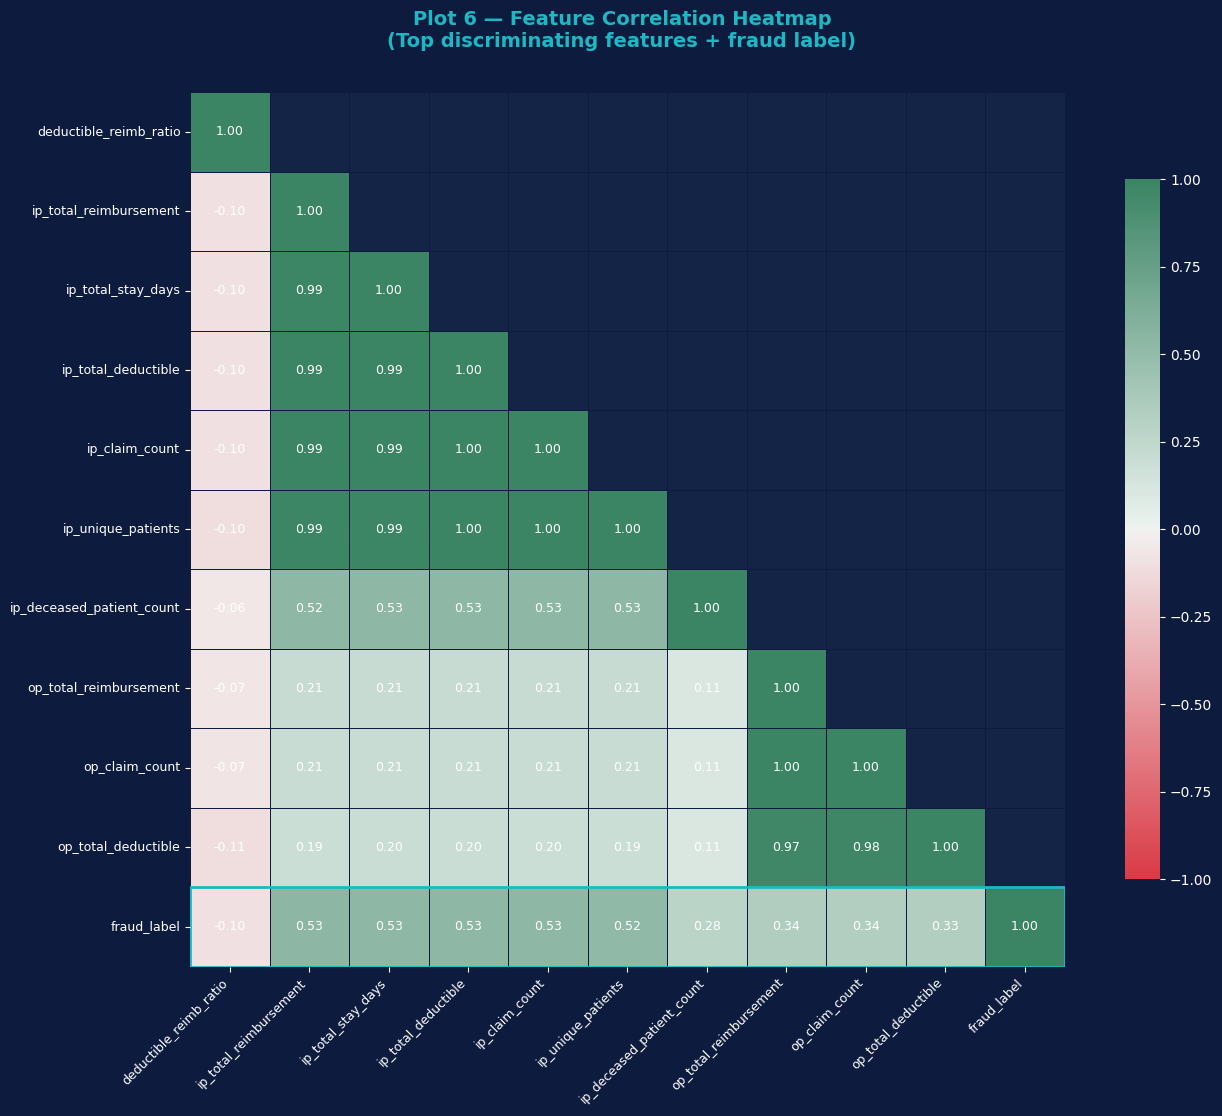


🔍 Top correlations with fraud_label:
  (+) ip_total_reimbursement                   r = +0.533
  (+) ip_total_stay_days                       r = +0.526
  (+) ip_total_deductible                      r = +0.525
  (+) ip_claim_count                           r = +0.525
  (+) ip_unique_patients                       r = +0.522
  (+) op_total_reimbursement                   r = +0.338
  (+) op_claim_count                           r = +0.336
  (+) op_total_deductible                      r = +0.329


In [ ]:
numeric_df = df.select_dtypes(include=[np.number]).copy()

# Select most informative features to keep heatmap readable
keep = top_features + ['fraud_label']
keep = [c for c in keep if c in numeric_df.columns]
corr_df = numeric_df[keep].corr()

fig, ax = plt.subplots(figsize=(14, 11))
fig.suptitle('Plot 6 — Feature Correlation Heatmap\n(Top discriminating features + fraud label)',
             fontsize=14, fontweight='bold', color=ACCENT, y=1.01)

# Custom colormap: red = high positive corr, blue = high negative, white = zero
cmap = sns.diverging_palette(10, 150, as_cmap=True)

mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)  # Hide upper triangle

sns.heatmap(
    corr_df,
    ax=ax,
    mask=mask,
    cmap=cmap,
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 9, 'color': WHITE},
    linewidths=0.5,
    linecolor=NAVY,
    square=True,
    cbar_kws={'shrink': 0.8}
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

# Highlight the fraud_label row/column
fraud_idx = list(corr_df.columns).index('fraud_label')
ax.add_patch(plt.Rectangle((0, fraud_idx), len(corr_df), 1,
                             fill=False, edgecolor=ACCENT, lw=2))

plt.tight_layout()
save_plot(fig, 'plot6_correlation_heatmap.png')
plt.show()

print('\n🔍 Top correlations with fraud_label:')
fraud_corr = corr_df['fraud_label'].drop('fraud_label').abs().sort_values(ascending=False)
for col, val in fraud_corr.head(8).items():
    direction = '(+)' if corr_df.loc[col, 'fraud_label'] > 0 else '(-)'
    print(f'  {direction} {col:<40} r = {corr_df.loc[col, "fraud_label"]:+.3f}')

## Cell 11 — Plot 7: Outlier Detection (IQR method)

  💾 Saved → /content/drive/MyDrive/insurance_fraud/plots/plot7_outlier_analysis.png


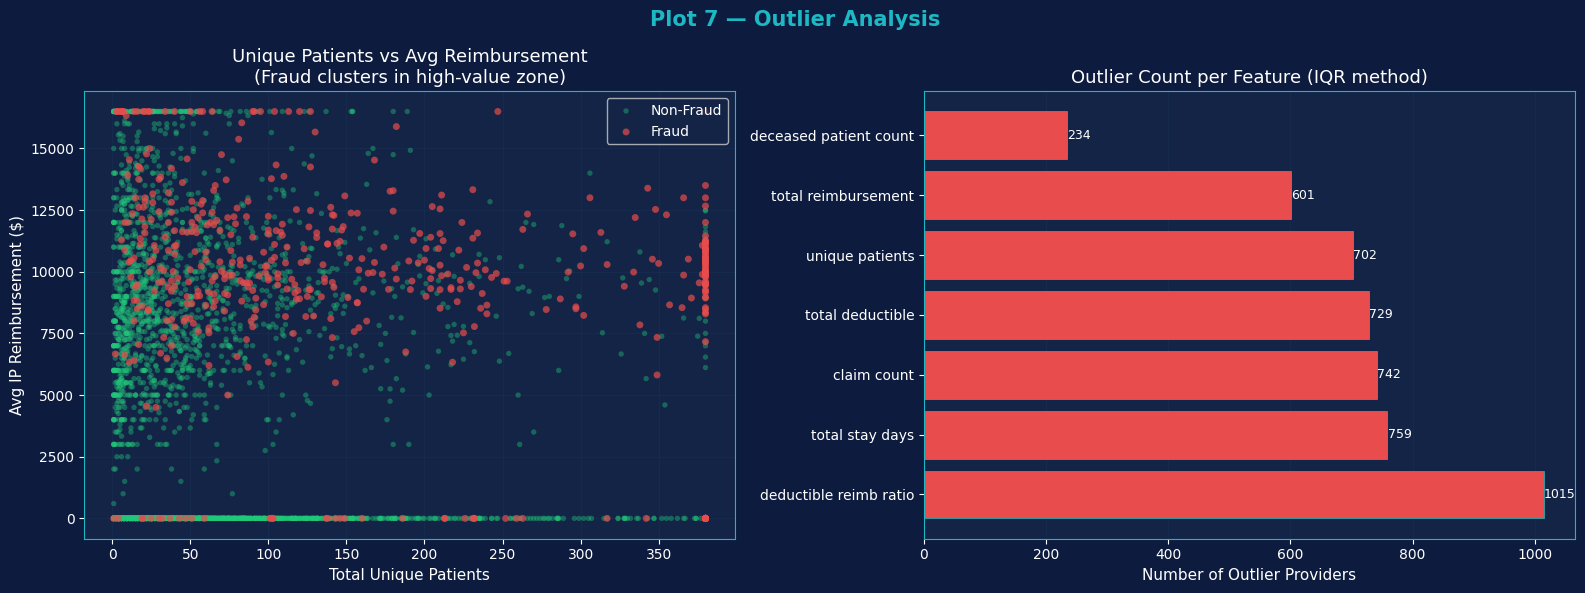

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Plot 7 — Outlier Analysis', fontsize=15, fontweight='bold', color=ACCENT)

# ── 1. Scatter: avg reimbursement vs unique patients, colored by fraud ─────────
ax = axes[0]
col_x = 'total_unique_patients'
col_y = 'ip_avg_reimbursement'

if col_x in df.columns and col_y in df.columns:
    cap_x = df[col_x].quantile(0.97)
    cap_y = df[col_y].quantile(0.97)

    ax.scatter(
        non_fraud[col_x].clip(0, cap_x),
        non_fraud[col_y].clip(0, cap_y),
        c=GREEN, alpha=0.4, s=15, label='Non-Fraud', edgecolors='none'
    )
    ax.scatter(
        fraud[col_x].clip(0, cap_x),
        fraud[col_y].clip(0, cap_y),
        c=RED, alpha=0.7, s=25, label='Fraud', edgecolors='none'
    )
    ax.set_xlabel('Total Unique Patients')
    ax.set_ylabel('Avg IP Reimbursement ($)')
    ax.set_title('Unique Patients vs Avg Reimbursement\n(Fraud clusters in high-value zone)')
    ax.legend()
    ax.yaxis.grid(True); ax.xaxis.grid(True)
    ax.set_axisbelow(True)

# ── 2. Outlier count per feature ──────────────────────────────────────────────
ax = axes[1]
outlier_counts = {}
for col in top_features[:8]:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
        outlier_counts[col.replace('ip_','').replace('op_','').replace('_',' ')] = outliers

if outlier_counts:
    sorted_items = sorted(outlier_counts.items(), key=lambda x: x[1], reverse=True)
    names, counts = zip(*sorted_items)
    colors = [RED if c > 50 else YELLOW if c > 20 else GREEN for c in counts]
    bars = ax.barh(names, counts, color=colors, edgecolor=ACCENT, linewidth=0.5)
    ax.set_title('Outlier Count per Feature (IQR method)')
    ax.set_xlabel('Number of Outlier Providers')
    ax.xaxis.grid(True)
    ax.set_axisbelow(True)
    for bar, val in zip(bars, counts):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9, color=WHITE)

plt.tight_layout()
save_plot(fig, 'plot7_outlier_analysis.png')
plt.show()

## Cell 12 — Plot 8: Fraud Rate by Feature Quantile (Risk Buckets)

  💾 Saved → /content/drive/MyDrive/insurance_fraud/plots/plot8_fraud_rate_by_quantile.png


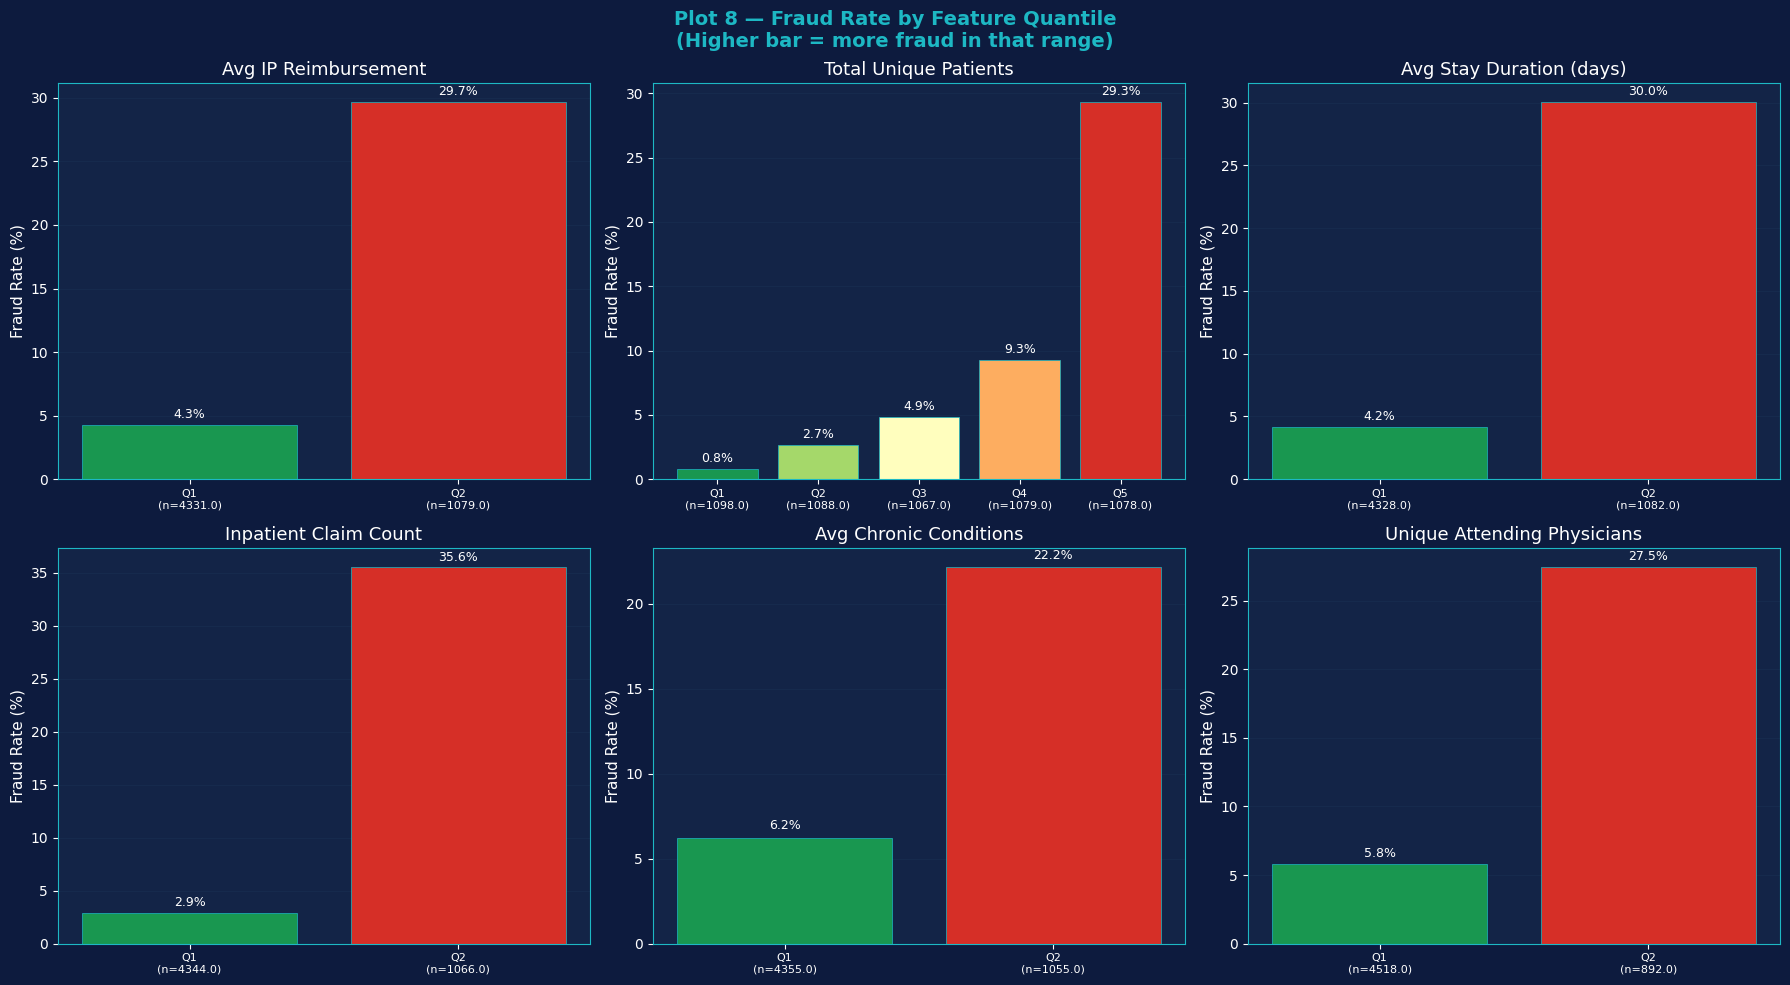

In [ ]:
# Shows: as a feature value increases, does fraud rate increase too?
# This is a key plot for your project report — shows non-linear fraud signals

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Plot 8 — Fraud Rate by Feature Quantile\n(Higher bar = more fraud in that range)',
             fontsize=14, fontweight='bold', color=ACCENT)

risk_features = [
    ('ip_avg_reimbursement',   'Avg IP Reimbursement'),
    ('total_unique_patients',  'Total Unique Patients'),
    ('ip_avg_stay_days',       'Avg Stay Duration (days)'),
    ('ip_claim_count',         'Inpatient Claim Count'),
    ('ip_avg_chronic_cond',    'Avg Chronic Conditions'),
    ('ip_unique_attending_phys','Unique Attending Physicians'),
]
risk_features = [(c, l) for c, l in risk_features if c in df.columns]

for ax, (col, label) in zip(axes.flatten(), risk_features):
    # Split into 5 quantile buckets
    try:
        df['_bucket'] = pd.qcut(df[col], q=5, duplicates='drop', labels=False)
        bucket_fraud  = df.groupby('_bucket')['fraud_label'].agg(['mean', 'count']).reset_index()
        bucket_fraud.columns = ['bucket', 'fraud_rate', 'count']

        # Bar colors: gradient from green to red based on fraud rate
        bar_colors = plt.cm.RdYlGn_r(
            np.linspace(0.1, 0.9, len(bucket_fraud))
        )
        bars = ax.bar(
            range(len(bucket_fraud)),
            bucket_fraud['fraud_rate'] * 100,
            color=bar_colors,
            edgecolor=ACCENT, linewidth=0.5
        )
        ax.set_xticks(range(len(bucket_fraud)))
        ax.set_xticklabels([f'Q{i+1}\n(n={r["count"]})'
                            for i, r in bucket_fraud.iterrows()], fontsize=8)
        ax.set_title(label)
        ax.set_ylabel('Fraud Rate (%)')
        ax.yaxis.grid(True); ax.set_axisbelow(True)

        for bar, val in zip(bars, bucket_fraud['fraud_rate']):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.3,
                    f'{val*100:.1f}%',
                    ha='center', va='bottom', fontsize=9, color=WHITE)

        df.drop(columns=['_bucket'], inplace=True)
    except Exception as e:
        ax.text(0.5, 0.5, f'Could not plot:\n{col}', ha='center', va='center',
                transform=ax.transAxes, color=GRAY, fontsize=10)

plt.tight_layout()
save_plot(fig, 'plot8_fraud_rate_by_quantile.png')
plt.show()

## Cell 13 — EDA Summary Report

In [ ]:
print('='*65)
print('  M2 EDA SUMMARY — KEY FINDINGS')
print('='*65)

findings = []

# Finding 1: Reimbursement gap
if 'ip_avg_reimbursement' in df.columns:
    nf_r = non_fraud['ip_avg_reimbursement'].mean()
    f_r  = fraud['ip_avg_reimbursement'].mean()
    findings.append(f'Fraudulent providers bill {f_r/nf_r:.1f}x higher avg IP reimbursement '
                    f'(${f_r:,.0f} vs ${nf_r:,.0f})')

# Finding 2: Unique patients
if 'total_unique_patients' in df.columns:
    nf_p = non_fraud['total_unique_patients'].mean()
    f_p  = fraud['total_unique_patients'].mean()
    findings.append(f'Fraud providers serve {f_p/nf_p:.1f}x more unique patients on average '
                    f'({f_p:.0f} vs {nf_p:.0f})')

# Finding 3: Stay duration
if 'ip_avg_stay_days' in df.columns:
    nf_s = non_fraud['ip_avg_stay_days'].mean()
    f_s  = fraud['ip_avg_stay_days'].mean()
    findings.append(f'Avg hospital stay is {f_s:.1f} days for fraud vs {nf_s:.1f} for legit '
                    f'({f_s/max(nf_s,0.01):.1f}x longer)')

# Finding 4: Chronic conditions
if 'ip_avg_chronic_cond' in df.columns:
    nf_c = non_fraud['ip_avg_chronic_cond'].mean()
    f_c  = fraud['ip_avg_chronic_cond'].mean()
    findings.append(f'Fraud providers bill {f_c:.2f} avg chronic conditions vs {nf_c:.2f} '
                    f'(diagnosis stuffing signal)')

# Finding 5: Unique physicians
if 'ip_unique_attending_phys' in df.columns:
    nf_ph = non_fraud['ip_unique_attending_phys'].mean()
    f_ph  = fraud['ip_unique_attending_phys'].mean()
    findings.append(f'Fraud providers use {f_ph:.1f} unique physicians vs {nf_ph:.1f} '
                    f'(physician reuse / ring signal)')

for i, f in enumerate(findings, 1):
    print(f'\n  Finding {i}:')
    print(f'    → {f}')

print(f'\n  Top correlated feature with fraud_label:')
top_corr = corr_df['fraud_label'].drop('fraud_label').abs().idxmax()
top_val  = corr_df.loc[top_corr, 'fraud_label']
print(f'    → {top_corr}  (r = {top_val:+.3f})')

print(f'\n  📁 Plots saved to: {PLOT_DIR}')
print(f'     plot1_class_distribution.png')
print(f'     plot2_financial_signals.png')
print(f'     plot3_patient_volume.png')
print(f'     plot4_physician_stay.png')
print(f'     plot5_top_features_boxplot.png')
print(f'     plot6_correlation_heatmap.png')
print(f'     plot7_outlier_analysis.png')
print(f'     plot8_fraud_rate_by_quantile.png')

print('='*65)

  M2 EDA SUMMARY — KEY FINDINGS

  Finding 1:
    → Fraudulent providers bill 2.9x higher avg IP reimbursement ($9,605 vs $3,364)

  Finding 2:
    → Fraud providers serve 5.0x more unique patients on average (248 vs 49)

  Finding 3:
    → Avg hospital stay is 5.3 days for fraud vs 1.9 for legit (2.8x longer)

  Finding 4:
    → Fraud providers bill 4.83 avg chronic conditions vs 1.85 (diagnosis stuffing signal)

  Finding 5:
    → Fraud providers use 8.2 unique physicians vs 1.6 (physician reuse / ring signal)

  Top correlated feature with fraud_label:
    → ip_total_reimbursement  (r = +0.533)

  📁 Plots saved to: /content/drive/MyDrive/insurance_fraud/plots/
     plot1_class_distribution.png
     plot2_financial_signals.png
     plot3_patient_volume.png
     plot4_physician_stay.png
     plot5_top_features_boxplot.png
     plot6_correlation_heatmap.png
     plot7_outlier_analysis.png
     plot8_fraud_rate_by_quantile.png

📌 Next: Open M3_Feature_Engineering.ipynb
